In [1]:
import yaml
from pathlib import Path
from msm_agent.stage import run_stage1_featurization, run_stage2_tica_scan, run_stage3_tica_fit, run_stage4_cluster, run_stage5_msm_scan, run_stage6_msm_fit, run_stage7_lumpeval

cfg = yaml.safe_load(open("../examples/interactive_pipeline.yaml"))
run_dir = Path("./runs/debug_run_tmp")


In [2]:
re1 = run_stage1_featurization(cfg, run_dir)

In [3]:
re1

{'success': True,
 'stage': 'stage1_featurization',
 'run_dir': 'runs/debug_run_tmp',
 'summary': 'Stage 1 completed: data loading and featurization finished.\nRun dir: runs/debug_run_tmp\nData kind: xtc\nNumber of trajectories: 2\nEffective timestep: 1.0000 ps\nFeature type: distance\nFeature selection: distances\nAtom selection: HEAVY\nTrajectory length range (frames): min=10001, max=10001\nFeature dimension(s): [45]\nSaved features: runs/debug_run_tmp/features\n\nPlease review whether this featurization is acceptable. You can keep it or modify feature-related config and rerun Stage 1.',
 'plot_path': None,
 'manifest_path': 'runs/debug_run_tmp/stage1_manifest.json'}

In [4]:
re2 = run_stage2_tica_scan(cfg, run_dir)

/mnt/g/agent/MSM-AGENT/msm_agent/plots.py:56: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


In [5]:
re2

{'success': True,
 'stage': 'stage2_tica_param_scan',
 'run_dir': 'runs/debug_run_tmp',
 'summary': 'Stage 2 completed: tICA lag scan finished.\nRun dir: runs/debug_run_tmp\nScan lag range (in frames): 1 to 50\nScan n_components: 4\nEffective timestep: 0.001000 ns\nITS plot: runs/debug_run_tmp/figs/tica_its_curve.png\nAuto plateau check: for top 3 components, the last 4 steps are [True, True, True, True]\n\nPlease review the ITS curve. You can keep the current scan settings, change scan parameters, or set final tICA parameters for Stage 3.',
 'plot_path': 'runs/debug_run_tmp/figs/tica_its_curve.png',
 'manifest_path': 'runs/debug_run_tmp/stage2_manifest.json'}

In [6]:
# after inspecting the tica its and set lagtime
cfg['tica']['selected_lag_time'] = 10

In [7]:
re3 = run_stage3_tica_fit(cfg, re2['run_dir'])

In [8]:
re3

{'success': True,
 'stage': 'stage3_tica_fit',
 'run_dir': 'runs/debug_run_tmp',
 'summary': 'Stage 3 completed: final tICA fit finished.\nRun dir: runs/debug_run_tmp\nSelected lag_time (frames): 10\nSelected n_components: 4\nSaved tICA trajectories: runs/debug_run_tmp/tica_trajs\ntICA trajectory shapes: [[10001, 4], [10001, 4]]\nDensity plot: runs/debug_run_tmp/figs/tica_density_hexbin.png\n\nPlease review the final tICA embedding. If it looks reasonable, you can proceed to clustering in the next phase.',
 'plot_path': 'runs/debug_run_tmp/figs/tica_density_hexbin.png',
 'manifest_path': 'runs/debug_run_tmp/stage3_manifest.json'}

In [2]:
re4 = run_stage4_cluster(cfg, run_dir)

In [3]:
re4

{'success': True,
 'stage': 'stage4_cluster',
 'run_dir': 'runs/debug_run_tmp',
 'summary': 'Stage 4 completed: clustering finished.\nRun dir: runs/debug_run_tmp\nCluster type: KMeans\nCluster n_clusters: 50\nSaved clustered trajectories: runs/debug_run_tmp/cluster_trajs\nOccupied clusters: 50 out of 50 total clusters\nTiny clusters (occupancy < 10): 0.0000 fraction\n\nPlease review the clustering results. You can keep the current clustering settings or modify clustering-related config and rerun Stage 4.',
 'plot_path': 'runs/debug_run_tmp/figs/occupancy_hist.png',
 'manifest_path': 'runs/debug_run_tmp/stage4_manifest.json'}

In [2]:
re5 = run_stage5_msm_scan(cfg, run_dir)

In [3]:
re5

{'success': True,
 'stage': 'stage5_msm_scan',
 'run_dir': 'runs/debug_run_tmp',
 'summary': 'Stage 5 completed: MSM scanning finished.\nRun dir: runs/debug_run_tmp\n\nPlease review the MSM quality metrics. If there are sparsity warnings, try decreasing the MSM lag time or reducing the number of clusters.\nIf there are ITS warnings, consider increasing the MSM lag time . After adjusting parameters, rerun Stage 5.',
 'plot_path': 'runs/debug_run_tmp/figs/microstateMSM_its_curve.png',
 'manifest_path': 'runs/debug_run_tmp/stage5_manifest.json'}

In [2]:
cfg['microMSM']['selected_lag_time'] = 10

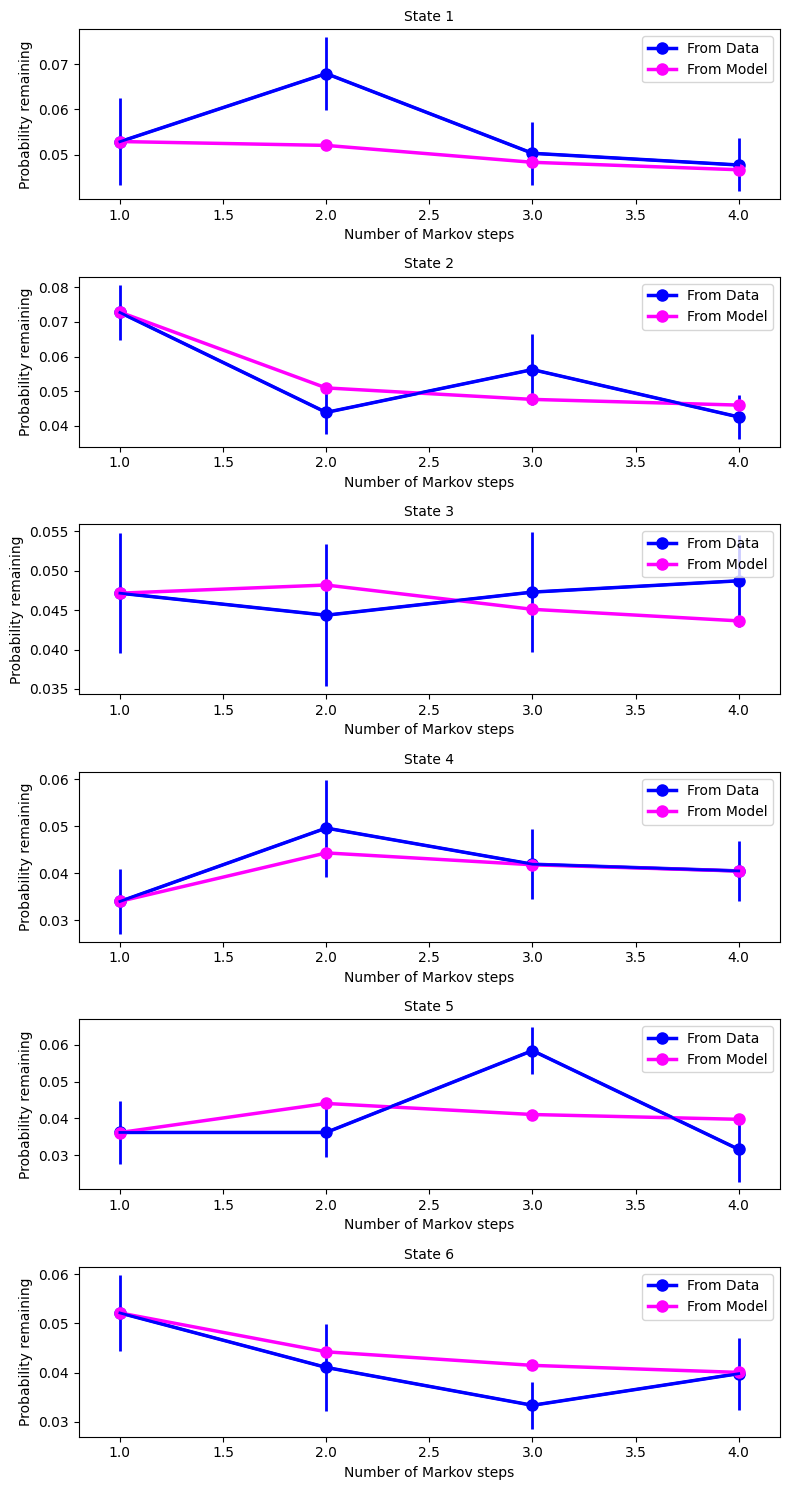

In [3]:
re6 = run_stage6_msm_fit(cfg, run_dir)

In [4]:
re6

{'success': True,
 'stage': 'stage6_msm_fit',
 'run_dir': 'runs/debug_run_tmp',
 'summary': 'Stage 6 completed: microstateMSM fit and quality test finished.\nRun dir: runs/debug_run_tmp\nCaptured timescales (ns): [0.0645261  0.00395709 0.00394081 0.00390207 0.0037476 ]\nCK test pass: True with note prediction within the 95% confidence interval\n\nPlease review the MSM test results. Note that the estimated timescales will be slower after lumping.',
 'plot_path': [PosixPath('runs/debug_run_tmp/figs/CK_test.png'),
  PosixPath('runs/debug_run_tmp/figs/weighted_freeenergy.png')],
 'manifest_path': 'runs/debug_run_tmp/stage6_manifest.json'}

In [5]:
re7 = run_stage7_lumpeval(cfg, run_dir)

Optimization terminated successfully.
         Current function value: -1.932864
         Iterations: 19
         Function evaluations: 119


/opt/anaconda3/envs/agent/lib/python3.11/site-packages/scipy/optimize/_numdiff.py:686: RuntimeWarning: invalid value encountered in subtract
  df = [f_eval - f0 for f_eval in f_evals]
/opt/anaconda3/envs/agent/lib/python3.11/site-packages/msmbuilder/msm/msm.py:183: UserWarning: reversible_type='mle' and ergodic_cutoff <= 0 are not generally compatible
  warnings.warn("reversible_type='mle' and ergodic_cutoff <= 0 "


In [6]:
re7

{'success': True,
 'stage': 'stage7_lumpeval',
 'run_dir': 'runs/debug_run_tmp',
 'summary': 'Stage 7 completed: macrostate analysis finished.\nRun dir: runs/debug_run_tmp\nNumber of macrostates: 4\nMacrostate populations: [5340, 13682, 776, 204]\nCaptured timescales (ns): [0.06434323 0.00336254 0.00273142]\n\nPlease review the macrostate analysis results. You can adjust lumping parameters and rerun Stage 7 if needed.',
 'plot_path': None,
 'manifest_path': None}